# Day 04 — Delta P theo pathway

[Slide của buổi học](_static/slides/day04_slides.pptx)

## Mục tiêu

- Tạo xác suất dự đoán từ mô hình ring1
- Ghép với subset NGS gồm 64 bệnh nhân
- Tính delta mean P và delta median P cho từng pathway
- Vẽ được bar chart và boxplot để đọc kết quả

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import mannwhitneyu

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def raw_url(relative_path):
    return f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/{relative_path}"

def load_csv(relative_repo_path):
    local_candidates = [
        Path(relative_repo_path),
        Path("..") / relative_repo_path,
        Path("/content") / REPO_NAME / relative_repo_path,
    ]
    for p in local_candidates:
        if p.exists():
            return pd.read_csv(p)
    return pd.read_csv(raw_url(relative_repo_path))

def build_lr_pipeline(feature_list, cat_cols):
    num_cols = [c for c in feature_list if c not in cat_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), [c for c in feature_list if c in cat_cols]),
    ])
    pipe = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    return pipe

In [2]:
df = load_csv('data/nsclc_egfr_radiomics_simplified.csv')
ngs = load_csv('data/ngs_pathway_demo_64.csv')

target = 'egfr_mutation'
clinical = ['age','sex','smoking_status','histology','stage','tumor_size_mm','tumor_volume_cm3','tp53_mutation']
cat_cols = ['sex','smoking_status','histology','stage']
ring1 = [c for c in df.columns if c.startswith('ring1_')]
feature_list = clinical + ring1

pipe = build_lr_pipeline(feature_list, cat_cols)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pred_prob_cv = cross_val_predict(pipe, df[feature_list], df[target], cv=cv, method='predict_proba')[:, 1]

pred_df = df[['patient_id', 'egfr_mutation']].copy()
pred_df['pred_prob_egfr'] = pred_prob_cv

merged = ngs.merge(pred_df, on=['patient_id', 'egfr_mutation'], how='left')
display(merged.head())

,patient_id,egfr_mutation,pathway_RTK_RAS,pathway_PI3K,pathway_DNA_repair,pathway_Cell_cycle,pathway_TP53,pred_prob_egfr
0,P096,1,0,0,1,1,0,0.592529
1,P016,0,0,0,0,0,1,0.435759
2,P031,1,0,0,1,1,1,0.986109
3,P159,0,0,0,0,1,0,0.946312
4,P129,0,1,1,0,0,1,0.063972


## Bước 1 — Tạo bảng pathway

Bảng này chính là cầu nối giữa machine learning và radiogenomics.

In [3]:
path_cols = [c for c in merged.columns if c.startswith('pathway_')]
rows = []

for c in path_cols:
    g_mut = merged.loc[merged[c] == 1, 'pred_prob_egfr']
    g_wt = merged.loc[merged[c] == 0, 'pred_prob_egfr']
    _, p_value = mannwhitneyu(g_mut, g_wt, alternative='two-sided')

    rows.append({
        'pathway': c.replace('pathway_', ''),
        'n_mut': int((merged[c] == 1).sum()),
        'median_mut': g_mut.median(),
        'median_wt': g_wt.median(),
        'delta_median_p': g_mut.median() - g_wt.median(),
        'mean_mut': g_mut.mean(),
        'mean_wt': g_wt.mean(),
        'delta_mean_p': g_mut.mean() - g_wt.mean(),
        'mannwhitney_p': p_value
    })

pathway_table = pd.DataFrame(rows).sort_values('delta_median_p', ascending=False).round(3)
display(pathway_table)

,pathway,n_mut,median_mut,median_wt,delta_median_p,mean_mut,mean_wt,delta_mean_p,mannwhitney_p
1,PI3K,24,0.612,0.378,0.233,0.569,0.411,0.159,0.084
3,Cell_cycle,24,0.482,0.387,0.096,0.493,0.457,0.037,0.662
2,DNA_repair,19,0.482,0.426,0.057,0.544,0.439,0.105,0.370
0,RTK_RAS,22,0.410,0.431,-0.020,0.464,0.473,-0.009,0.871
4,TP53,28,0.404,0.437,-0.032,0.451,0.485,-0.033,0.720


## Bước 2 — Vẽ bar chart của delta median P

Bar chart giúp nhìn rất nhanh pathway nào đứng đầu.

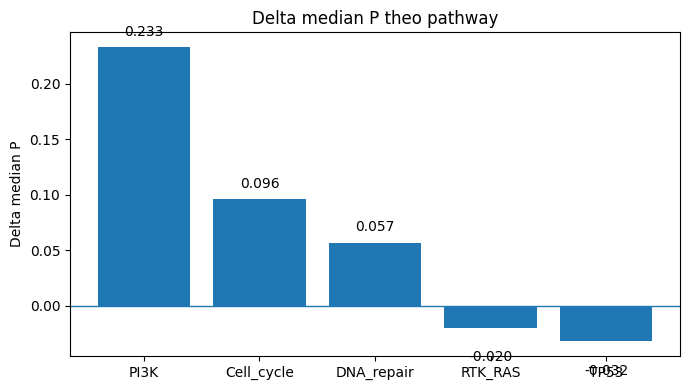

In [4]:
plt.figure(figsize=(7, 4))
plt.bar(pathway_table['pathway'], pathway_table['delta_median_p'])
plt.axhline(0, linewidth=1)
for i, v in enumerate(pathway_table['delta_median_p']):
    plt.text(i, v + (0.01 if v >= 0 else -0.03), f'{v:.3f}', ha='center')
plt.ylabel('Delta median P')
plt.title('Delta median P theo pathway')
plt.tight_layout()
plt.show()

## Bước 3 — Xem boxplot của pathway đứng đầu

Day 04 không dừng ở bảng số. Học sinh cần nhìn thấy phân bố xác suất của nhóm mutated và WT.

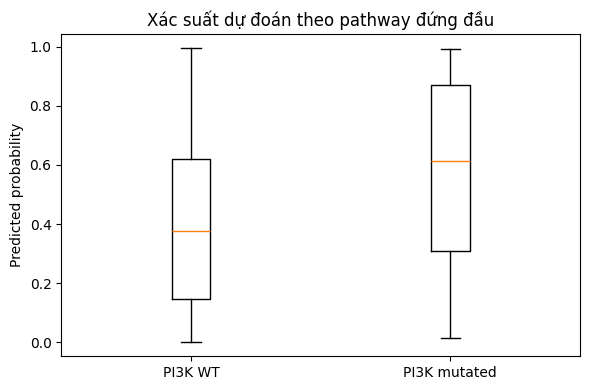

,Nhóm,Median P,Mean P
0,PI3K WT,0.378,0.411
1,PI3K mutated,0.612,0.569


In [5]:
top_pathway = pathway_table.iloc[0]['pathway']
top_col = 'pathway_' + top_pathway

mut_group = merged.loc[merged[top_col] == 1, 'pred_prob_egfr']
wt_group = merged.loc[merged[top_col] == 0, 'pred_prob_egfr']

plt.figure(figsize=(6, 4))
plt.boxplot([wt_group, mut_group], tick_labels=[top_pathway + ' WT', top_pathway + ' mutated'])
plt.ylabel('Predicted probability')
plt.title('Xác suất dự đoán theo pathway đứng đầu')
plt.tight_layout()
plt.show()

summary_box = pd.DataFrame({
    'Nhóm': [top_pathway + ' WT', top_pathway + ' mutated'],
    'Median P': [wt_group.median(), mut_group.median()],
    'Mean P': [wt_group.mean(), mut_group.mean()]
}).round(3)
display(summary_box)

## Kết quả demo của Day 04

Trong bộ demo hiện tại, pathway đứng đầu là PI3K.

- Delta median P của pathway này là 0.233
- Delta mean P là 0.159
- p value của Mann Whitney là 0.084

Cách đọc rất đơn giản. Nếu delta median P dương và đủ lớn thì nhóm mutated đang có xác suất dự đoán EGFR cao hơn nhóm WT.

## Sản phẩm sau bài học

- Một bảng pathway đầy đủ
- Một bar chart của delta median P
- Một boxplot của pathway đứng đầu
- Hai đến ba câu diễn giải sinh học ở mức vừa phải

## Tự kiểm tra

1. Vì sao Day 04 dùng predicted probability thay vì nhãn 0 và 1
2. Delta median P khác gì delta mean P
3. Boxplot của pathway đứng đầu cho thấy điều gì